In [ ]:

%%writefile ew_model.py
import math

def calculate_ew_metrics(J_app, flow_rate_L_min, temp_C, C_in_g_L):
    """
    Calculates efficiency, production rate, and outlet concentration.
    Returns: (efficiency_percent, copper_g_min, C_out_g_L)
    """
    # Handle near-zero inputs to prevent division by zero errors
    if flow_rate_L_min <= 0.01: flow_rate_L_min = 0.01
    if J_app <= 0.01: J_app = 0.01
    if C_in_g_L <= 0.0: C_in_g_L = 0.001

    # Geometry (1m x 1m, 16 faces, 1cm holes, 2cm pitch)
    plate_width = 1.0
    plate_length = 1.0
    n_faces = 160
    d_hole = 0.01
    pitch = 0.02

    z = 2.0
    F = 96485.0
    M_cu = 63.546

    # Temperature & Physical Properties
    T_K = temp_C + 273.15
    mu_water = 2.414e-5 * math.pow(10, (247.8 / (T_K - 140.0)))
    rho_water = 1000 * (1 - ((temp_C + 288.9414) / (508929.2 * (temp_C + 68.12963))) * (temp_C - 3.9863)**2)
    nu_actual = mu_water / rho_water

    D_cu_actual = 6.0e-10 * (T_K / 298.15) * (8.90e-4 / mu_water)

    # Areas
    plate_area = plate_width * plate_length
    n_holes_per_face = (plate_width / pitch) * (plate_length / pitch)
    a_jet_single = math.pi * (d_hole / 2)**2

    A_jet_total = n_faces * n_holes_per_face * a_jet_single
    A_dead_total = n_faces * (plate_area - (n_holes_per_face * a_jet_single))
    A_total = A_jet_total + A_dead_total

    # Fluid Dynamics
    flow_m3_s = flow_rate_L_min / (1000.0 * 60.0)
    v_jet = flow_m3_s / (n_holes_per_face * a_jet_single)

    Re_jet = (v_jet * d_hole) / nu_actual
    Sc = nu_actual / D_cu_actual

    # Mass Transfer Limits
    Sh_jet = 1.0 * math.sqrt(Re_jet) * (Sc**0.33)
    k_jet = (Sh_jet * D_cu_actual) / d_hole
    k_dead = k_jet * 0.15

    c_bulk_mol_m3 = (C_in_g_L / M_cu) * 1000.0

    J_lim_jet = z * F * k_jet * c_bulk_mol_m3
    J_lim_dead = z * F * k_dead * c_bulk_mol_m3

    # Regime Selection
    J_actual_jet = min(J_app, J_lim_jet)
    J_actual_dead = min(J_app, J_lim_dead)

    # Calculations
    I_app_total = J_app * A_total
    I_actual_total = (J_actual_jet * A_jet_total) + (J_actual_dead * A_dead_total)

    # 1. Current Efficiency
    efficiency = (I_actual_total / I_app_total) * 100.0

    # 2. Production Rate (g/min)
    copper_g_min_theoretical = (I_actual_total * M_cu * 60.0) / (z * F)

    # Mass Conservation Check (Cannot extract more than flows in)
    mass_in_g_min = flow_rate_L_min * C_in_g_L
    copper_g_min = min(copper_g_min_theoretical, mass_in_g_min)

    # 3. Outlet Concentration (g/L)
    mass_out_g_min = mass_in_g_min - copper_g_min
    C_out_g_L = mass_out_g_min / flow_rate_L_min

    return efficiency, copper_g_min, C_out_g_L

Writing ew_model.py


### 1. Visualization of System Current Efficiency
The following block generates a 3D surface plot to visualize how current efficiency changes relative to current density, flow rate, and electrolyte temperature.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from ew_model import calculate_ew_metrics

# ==========================================
# SET YOUR INLET CONCENTRATION HERE
# ==========================================
INLET_CONC_G_L = 3.0
# ==========================================

J_grid = np.linspace(1, 200, 50)
Flow_grid = np.linspace(1, 200, 50)
X, Y = np.meshgrid(J_grid, Flow_grid)

temperatures = [30, 40, 50]
colorscales = ['Blues', 'Greens', 'Reds']

fig = go.Figure()

for i, temp in enumerate(temperatures):
    Z_eff = np.zeros_like(X)

    for row in range(X.shape[0]):
        for col in range(X.shape[1]):
            # Passing the new concentration variable into the engine
            eff, _, _ = calculate_ew_metrics(X[row, col], Y[row, col], temp, INLET_CONC_G_L)
            Z_eff[row, col] = eff

    fig.add_trace(go.Surface(
        z=Z_eff, x=X, y=Y,
        name=f'{temp}°C',
        colorscale=colorscales[i],
        opacity=0.8,
        showscale=False
    ))

fig.update_layout(
    title=f'System Current Efficiency (Inlet: {INLET_CONC_G_L} g/L Cu)',
    scene=dict(
        xaxis_title='Current Density (A/m²)',
        yaxis_title='Flowrate (L/min)',
        zaxis_title='Current Efficiency (%)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

### 2. Visualization of Copper Production Rate
This block calculates and plots the theoretical copper production rate (g/min) across different operational parameters.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from ew_model import calculate_ew_metrics

# ==========================================
# SET YOUR INLET CONCENTRATION HERE
# ==========================================
INLET_CONC_G_L = 3.0
# ==========================================

J_grid = np.linspace(1, 200, 50)
Flow_grid = np.linspace(1, 200, 50)
X, Y = np.meshgrid(J_grid, Flow_grid)

temperatures = [30, 40, 50]
colorscales = ['Blues', 'Greens', 'Reds']

fig = go.Figure()

for i, temp in enumerate(temperatures):
    Z_prod = np.zeros_like(X)

    for row in range(X.shape[0]):
        for col in range(X.shape[1]):
            _, prod, _ = calculate_ew_metrics(X[row, col], Y[row, col], temp, INLET_CONC_G_L)
            Z_prod[row, col] = prod

    fig.add_trace(go.Surface(
        z=Z_prod, x=X, y=Y,
        name=f'{temp}°C',
        colorscale=colorscales[i],
        opacity=0.8,
        showscale=False
    ))

fig.update_layout(
    title=f'Copper Production Rate (Inlet: {INLET_CONC_G_L} g/L Cu)',
    scene=dict(
        xaxis_title='Current Density (A/m²)',
        yaxis_title='Flowrate (L/min)',
        zaxis_title='Production (g/min)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

### 3. Visualization of Outlet Copper Concentration
This section models the remaining copper concentration in the electrolyte after it passes through the cell.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from ew_model import calculate_ew_metrics

# ==========================================
# SET YOUR INLET CONCENTRATION HERE
# ==========================================
INLET_CONC_G_L = 3.0
# ==========================================

J_grid = np.linspace(1, 200, 50)
Flow_grid = np.linspace(1, 200, 50)
X, Y = np.meshgrid(J_grid, Flow_grid)

temperatures = [30, 40, 50]
colorscales = ['Blues', 'Greens', 'Reds']

fig = go.Figure()

for i, temp in enumerate(temperatures):
    Z_cout = np.zeros_like(X)

    for row in range(X.shape[0]):
        for col in range(X.shape[1]):
            _, _, cout = calculate_ew_metrics(X[row, col], Y[row, col], temp, INLET_CONC_G_L)
            Z_cout[row, col] = cout

    fig.add_trace(go.Surface(
        z=Z_cout, x=X, y=Y,
        name=f'{temp}°C',
        colorscale=colorscales[i],
        opacity=0.8,
        showscale=False
    ))

fig.update_layout(
    title=f'Outlet Copper Concentration (Inlet: {INLET_CONC_G_L} g/L Cu)',
    scene=dict(
        xaxis_title='Current Density (A/m²)',
        yaxis_title='Flowrate (L/min)',
        zaxis_title='Outlet Concentration (g/L)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)
fig.show()

### 4. Pressure Drop Modeling: Orifice Model
Here we define a function to estimate the hydraulic resistance and pressure drop across the electrode stack using an orifice-based calculation.

In [ ]:
import math

def calculate_pressure_drop_orifice(flow_rate_L_min, rho_water, n_faces=160,
                                    plate_width=1.0, plate_length=1.0,
                                    d_hole=0.01, pitch=0.02, K_loss=2.0):
    """
    Calculates total pressure drop across the EW cell using the Orifice Model.
    Returns: Total pressure drop in Pascals (Pa)
    """
    # 1. System Geometry Setup
    n_plates = n_faces / 2.0  # Assuming 2 active faces per cathode plate
    A_cross_section = plate_width * plate_length

    # Calculate open area fraction (phi)
    n_holes_per_plate = (plate_width / pitch) * (plate_length / pitch)
    a_hole_single = math.pi * (d_hole / 2.0)**2
    total_hole_area = n_holes_per_plate * a_hole_single
    phi = total_hole_area / A_cross_section

    # 2. Fluid Dynamics
    flow_m3_s = flow_rate_L_min / (1000.0 * 60.0)

    # Superficial velocity (velocity if cell was empty)
    v_superficial = flow_m3_s / A_cross_section

    # Velocity strictly inside the narrow holes
    v_hole = v_superficial / phi

    # 3. Orifice Pressure Drop Calculation
    # DP per plate = K * 0.5 * rho * v_hole^2
    delta_p_per_plate = K_loss * 0.5 * rho_water * (v_hole**2)

    # Total pressure drop across all plates in series
    delta_p_total_Pa = n_plates * delta_p_per_plate

    return delta_p_total_Pa

### 5. Pressure Drop Modeling: Ergun Equation
This block provides an alternative pressure drop calculation based on porous media theory (the Ergun equation) for comparison.

In [ ]:
import math

def calculate_pressure_drop_ergun(flow_rate_L_min, mu_water, rho_water,
                                  n_faces=160, plate_width=1.0, plate_length=1.0,
                                  d_hole=0.01, pitch=0.02,
                                  plate_thickness_m=0.005, plate_spacing_m=0.05):
    """
    Calculates total pressure drop across the EW cell using the Modified Ergun Equation.
    Returns: Total pressure drop in Pascals (Pa)
    """
    # 1. System Geometry Setup
    n_plates = n_faces / 2.0
    A_cross_section = plate_width * plate_length
    L_total = n_plates * (plate_thickness_m + plate_spacing_m) # Total length of plate stack

    # Calculate open area fraction (phi)
    n_holes_per_plate = (plate_width / pitch) * (plate_length / pitch)
    a_hole_single = math.pi * (d_hole / 2.0)**2
    total_hole_area = n_holes_per_plate * a_hole_single
    phi = total_hole_area / A_cross_section

    # 2. Derive Equivalent Porous Bed Parameters
    t = plate_thickness_m
    s = plate_spacing_m

    # Equivalent Porosity (void volume fraction)
    epsilon_eq = (phi * t + s) / (t + s)

    # Specific Surface Area (wetted area per unit volume)
    a_v = (2.0 * (1.0 - phi) + (4.0 * phi * t) / d_hole) / (t + s)

    # Equivalent Particle Diameter
    Dp_eq = (6.0 * (1.0 - epsilon_eq)) / a_v

    # 3. Fluid Dynamics
    flow_m3_s = flow_rate_L_min / (1000.0 * 60.0)
    v_superficial = flow_m3_s / A_cross_section

    # 4. Modified Ergun Equation Calculation
    # Viscous (laminar) friction term
    viscous_term = 150.0 * ((mu_water * v_superficial) / (Dp_eq**2)) * (((1.0 - epsilon_eq)**2) / (epsilon_eq**3))

    # Inertial (turbulent) kinetic energy loss term
    inertial_term = 1.75 * ((rho_water * (v_superficial**2)) / Dp_eq) * ((1.0 - epsilon_eq) / (epsilon_eq**3))

    # Total pressure drop per meter, multiplied by total length
    delta_p_per_m = viscous_term + inertial_term
    delta_p_total_Pa = delta_p_per_m * L_total

    return delta_p_total_Pa

### 6. Hydraulic Performance Analysis
In this section, we calculate and display the pressure drop results using both models for a specific system configuration.

In [ ]:
import math

# --- 1. FILL IN YOUR SPECIFIC SYSTEM PARAMETERS HERE ---
my_flow_rate_L_min = 200.0  # UPDATED: 200 L/min
my_temp_C = 45.0            # Assuming 45 degrees Celsius

# The physical parameters needed for pressure drop:
my_plate_thickness = 0.005  # CONFIRMED: 5 mm (0.005 m) thin plates
my_plate_spacing = 0.05     # Standard spacing: 5 cm (0.05 m) between plates
my_K_loss = 2.0             # Standard orifice loss coefficient

# Known geometry from your original script
my_n_faces = 160            # 80 plates total
my_width = 1.0              # CONFIRMED: 1m width
my_length = 1.0             # CONFIRMED: 1m length
my_d_hole = 0.01            # 1 cm hole diameter
my_pitch = 0.02             # 2 cm pitch


# --- 2. CALCULATE FLUID PROPERTIES (Based on your temperature) ---
T_K = my_temp_C + 273.15
# Dynamic Viscosity (mu)
my_mu_water = 2.414e-5 * math.pow(10, (247.8 / (T_K - 140.0)))
# Density (rho)
my_rho_water = 1000 * (1 - ((my_temp_C + 288.9414) / (508929.2 * (my_temp_C + 68.12963))) * (my_temp_C - 3.9863)**2)


# --- 3. CALL THE FUNCTIONS ---

# Call Function 1: The Orifice Model
pressure_drop_orifice_Pa = calculate_pressure_drop_orifice(
    flow_rate_L_min = my_flow_rate_L_min,
    rho_water = my_rho_water,
    n_faces = my_n_faces,
    plate_width = my_width,
    plate_length = my_length,
    d_hole = my_d_hole,
    pitch = my_pitch,
    K_loss = my_K_loss
)

# Call Function 2: The Modified Ergun Equation
pressure_drop_ergun_Pa = calculate_pressure_drop_ergun(
    flow_rate_L_min = my_flow_rate_L_min,
    mu_water = my_mu_water,
    rho_water = my_rho_water,
    n_faces = my_n_faces,
    plate_width = my_width,
    plate_length = my_length,
    d_hole = my_d_hole,
    pitch = my_pitch,
    plate_thickness_m = my_plate_thickness,
    plate_spacing_m = my_plate_spacing
)

# --- 4. PRINT THE RESULTS ---
print(f"--- Pressure Drop Results for {my_flow_rate_L_min} L/min at {my_temp_C}°C ---")
print(f"Orifice Model (Recommended): {pressure_drop_orifice_Pa:.2f} Pascals")
print(f"Modified Ergun Model:        {pressure_drop_ergun_Pa:.2f} Pascals")

# To convert to a more common industrial unit (kPa):
print(f"\nOrifice Model in kPa: {(pressure_drop_orifice_Pa / 1000):.4f} kPa")

--- Pressure Drop Results for 200.0 L/min at 45.0°C ---
Orifice Model (Recommended): 22.83 Pascals
Modified Ergun Model:        0.70 Pascals

Orifice Model in kPa: 0.0228 kPa


### 7. Sensitivity Analysis: Pitch Adjustment
This block re-evaluates the pressure drop specifically considering changes in electrode pitch (spacing).

In [ ]:
import math

def calculate_pressure_drop_orifice(flow_rate_L_min, rho_water, n_faces=160,
                                    plate_width=1.0, plate_length=1.0,
                                    d_hole=0.01, pitch=0.04, K_loss=2.0):
    n_plates = n_faces / 2.0
    A_cross_section = plate_width * plate_length

    n_holes_per_plate = (plate_width / pitch) * (plate_length / pitch)
    a_hole_single = math.pi * (d_hole / 2.0)**2
    total_hole_area = n_holes_per_plate * a_hole_single
    phi = total_hole_area / A_cross_section

    flow_m3_s = flow_rate_L_min / (1000.0 * 60.0)
    v_superficial = flow_m3_s / A_cross_section
    v_hole = v_superficial / phi

    delta_p_per_plate = K_loss * 0.5 * rho_water * (v_hole**2)
    delta_p_total_Pa = n_plates * delta_p_per_plate

    return delta_p_total_Pa

def calculate_pressure_drop_ergun(flow_rate_L_min, mu_water, rho_water,
                                  n_faces=160, plate_width=1.0, plate_length=1.0,
                                  d_hole=0.01, pitch=0.04,
                                  plate_thickness_m=0.005, plate_spacing_m=0.05):
    n_plates = n_faces / 2.0
    A_cross_section = plate_width * plate_length
    L_total = n_plates * (plate_thickness_m + plate_spacing_m)

    n_holes_per_plate = (plate_width / pitch) * (plate_length / pitch)
    a_hole_single = math.pi * (d_hole / 2.0)**2
    total_hole_area = n_holes_per_plate * a_hole_single
    phi = total_hole_area / A_cross_section

    t = plate_thickness_m
    s = plate_spacing_m

    epsilon_eq = (phi * t + s) / (t + s)
    a_v = (2.0 * (1.0 - phi) + (4.0 * phi * t) / d_hole) / (t + s)
    Dp_eq = (6.0 * (1.0 - epsilon_eq)) / a_v

    flow_m3_s = flow_rate_L_min / (1000.0 * 60.0)
    v_superficial = flow_m3_s / A_cross_section

    viscous_term = 150.0 * ((mu_water * v_superficial) / (Dp_eq**2)) * (((1.0 - epsilon_eq)**2) / (epsilon_eq**3))
    inertial_term = 1.75 * ((rho_water * (v_superficial**2)) / Dp_eq) * ((1.0 - epsilon_eq) / (epsilon_eq**3))

    delta_p_per_m = viscous_term + inertial_term
    delta_p_total_Pa = delta_p_per_m * L_total

    return delta_p_total_Pa

# --- EXECUTION BLOCK ---
my_flow_rate_L_min = 200.0
my_temp_C = 45.0
my_plate_thickness = 0.005
my_plate_spacing = 0.05
my_K_loss = 2.0
my_n_faces = 160
my_width = 1.0
my_length = 1.0
my_d_hole = 0.01
my_pitch = 0.04

T_K = my_temp_C + 273.15
my_mu_water = 2.414e-5 * math.pow(10, (247.8 / (T_K - 140.0)))
my_rho_water = 1000 * (1 - ((my_temp_C + 288.9414) / (508929.2 * (my_temp_C + 68.12963))) * (my_temp_C - 3.9863)**2)

pressure_drop_orifice_Pa = calculate_pressure_drop_orifice(
    flow_rate_L_min = my_flow_rate_L_min,
    rho_water = my_rho_water,
    n_faces = my_n_faces,
    plate_width = my_width,
    plate_length = my_length,
    d_hole = my_d_hole,
    pitch = my_pitch,
    K_loss = my_K_loss
)

pressure_drop_ergun_Pa = calculate_pressure_drop_ergun(
    flow_rate_L_min = my_flow_rate_L_min,
    mu_water = my_mu_water,
    rho_water = my_rho_water,
    n_faces = my_n_faces,
    plate_width = my_width,
    plate_length = my_length,
    d_hole = my_d_hole,
    pitch = my_pitch,
    plate_thickness_m = my_plate_thickness,
    plate_spacing_m = my_plate_spacing
)

print(f"--- Pressure Drop Results for {my_flow_rate_L_min} L/min at {my_temp_C}°C ---")
print(f"Pitch: {my_pitch} m")
print(f"Orifice Model (Recommended): {pressure_drop_orifice_Pa:.2f} Pascals")
print(f"Modified Ergun Model:        {pressure_drop_ergun_Pa:.2f} Pascals")
print(f"Orifice Model in kPa:        {(pressure_drop_orifice_Pa / 1000):.4f} kPa")

--- Pressure Drop Results for 200.0 L/min at 45.0°C ---
Pitch: 0.04 m
Orifice Model (Recommended): 365.30 Pascals
Modified Ergun Model:        0.74 Pascals
Orifice Model in kPa:        0.3653 kPa


### 8. Modeling the Concentration Gradient across the container
This script simulates the depletion of copper as the electrolyte moves through a multi-plate system, showing the concentration at each stage.

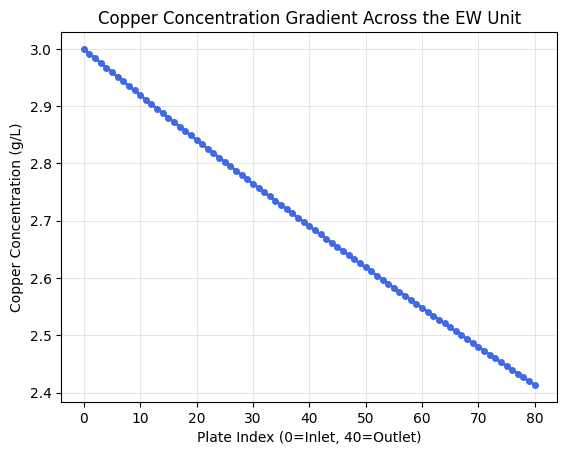

Inlet Concentration: 3.00 g/L
Final Outlet Concentration: 2.413 g/L


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

def calculate_gradient_profile(n_plates, flow_l_min, j_app, temp, inlet_c):
    # Setup for 1.0m x 1.0m cathodes (2 faces each)
    z, F, M_cu = 2.0, 96485.0, 63.546
    T_K = temp + 273.15
    plate_w, plate_l, d_hole, pitch = 1.0, 1.0, 0.01, 0.02

    # Physical constants (Water/Copper properties)
    mu = 2.414e-5 * math.pow(10, (247.8 / (T_K - 140.0)))
    rho = 1000 * (1 - ((temp + 288.9414) / (508929.2 * (temp + 68.12963))) * (temp - 3.9863)**2)
    nu, D_cu = mu / rho, 6.0e-10 * (T_K / 298.15) * (8.90e-4 / mu)

    # Mass transfer coefficient (k)
    n_holes = (plate_w / pitch) * (plate_l / pitch)
    a_jet = math.pi * (d_hole / 2)**2
    v_jet = (flow_l_min / 60000.0) / (n_holes * a_jet)
    k_jet = (1.0 * math.sqrt((v_jet * d_hole) / nu) * ((nu / D_cu)**0.33) * D_cu) / d_hole
    k_dead = k_jet * 0.15 # Dead zone factor

    # Electrode Area
    A_jet_total = 2 * n_holes * a_jet
    A_dead_total = 2 * (plate_w * plate_l - (n_holes * a_jet))

    concentrations = [inlet_c]
    current_c = inlet_c

    for i in range(n_plates):
        c_mol_m3 = (current_c / M_cu) * 1000.0
        I_act = (min(j_app, z * F * k_jet * c_mol_m3) * A_jet_total) + \
                (min(j_app, z * F * k_dead * c_mol_m3) * A_dead_total)

        prod_g_min = min((I_act * M_cu * 60.0) / (z * F), flow_l_min * current_c)
        current_c -= (prod_g_min / flow_l_min)
        concentrations.append(current_c)

    return concentrations

# EXECUTION: 40 plates, 150 L/min, 150 A/m2
n_plates = 80
profile = calculate_gradient_profile(n_plates, 150.0, 150.0, 40, 3.0)

# Plotting
plt.plot(range(n_plates + 1), profile, marker='o', color='royalblue', linewidth=2, markersize=4)
plt.title('Copper Concentration Gradient Across the EW Unit')
plt.xlabel('Plate Index (0=Inlet, 40=Outlet)')
plt.ylabel('Copper Concentration (g/L)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Inlet Concentration: {profile[0]:.2f} g/L")
print(f"Final Outlet Concentration: {profile[-1]:.3f} g/L")

### 9. Annual Production Estimates
Using the gradient profile, this block calculates the total daily recovery and projects the annual tonnage of copper produced.

In [ ]:
# Parameters
N_PLATES = 40
FLOW_RATE = 120.0   # L/min
J_APPLIED = 150.0   # A/m2
TEMPERATURE = 40.0
INITIAL_CONC = 4.0

# Calculate the profile for this specific scenario
final_profile = calculate_gradient_profile(N_PLATES, FLOW_RATE, J_APPLIED, TEMPERATURE, INITIAL_CONC)

# Production is the cumulative drop in concentration across the flow
total_prod_g_min = sum([(final_profile[i] - final_profile[i+1]) * FLOW_RATE for i in range(N_PLATES)])

# Annual conversion: (g/min * 60 * 24 * 365.25) / 1,000,000
annual_tonnage = (total_prod_g_min * 60 * 24 * 365.25) / 1_000_000

print(f"--- Production Results (120 L/min) ---")
print(f"Total Recovery Rate: {total_prod_g_min:.2f} g/min")
print(f"Yearly Tonnage: {annual_tonnage:.2f} Metric Tons/year")

--- Production Results (120 L/min) ---
Total Recovery Rate: 54.98 g/min
Yearly Tonnage: 28.92 Metric Tons/year


### 10. Solvent Extraction (SX) Circuit Design
Finally, this function calculates the required feed, organic, and reagent flow rates needed to support the upstream EW operations.

In [ ]:
def calculate_sx_circuit(c_in, q_out, c_out, ketoxime_pct=10.0, naoh_sol_conc=200.0):
    """
    Calculates required flow rates for a Copper SX circuit.

    Inputs:
    c_in: Aqueous feed Cu concentration (g/L)
    q_out: Target product flow rate (L/min)
    c_out: Target product Cu concentration (g/L)
    ketoxime_pct: % concentration of Ketoxime in organic phase (default 10%)
    naoh_sol_conc: Concentration of the NaOH solution used for pH (g/L) (default 200g/L)
    """
    # 1. Total Copper Mass Flow required (g/min)
    cu_mass_flow = q_out * c_out

    # 2. Required Aqueous Feed Flow (L/min)
    # How much source water do we need to process?
    q_feed_in = cu_mass_flow / c_in

    # 3. Required Organic (Ketoxime) Flow (L/min)
    # 1% v/v neat reagent can hold ~0.55 g/L.
    # We use a safety factor of 0.8 to avoid saturation.
    loading_capacity = (ketoxime_pct * 0.55) * 0.8
    q_organic = cu_mass_flow / loading_capacity

    # 4. NaOH Flow Rate for pH Control
    # Stoichiometry: 1 mole Cu (63.54g) releases 2 moles H+
    # 2 moles NaOH (2 * 40g = 80g) neutralizes 2 moles H+
    naoh_mass_needed = cu_mass_flow * (80.0 / 63.54) # grams of NaOH per minute
    q_naoh = naoh_mass_needed / naoh_sol_conc

    # 5. Sulfuric Acid Flow Rate
    # In a simple strip stage, the acid flow matches the target output flow
    q_acid_strip = q_out

    print(f"--- SX Circuit Calculation Results ---")
    print(f"Target Production:      {cu_mass_flow:.2f} g/min Cu")
    print(f"Required Feed Flow:     {q_feed_in:.2f} L/min")
    print(f"Organic Flow:           {q_organic:.2f} L/min (@ {ketoxime_pct}% Ketoxime)")
    print(f"NaOH Solution Flow:     {q_naoh:.2f} L/min (@ {naoh_sol_conc} g/L)")
    print(f"Strip Acid Flow:        {q_acid_strip:.2f} L/min")
    print(f"--------------------------------------")

# EXAMPLE: To get 120 L/min at 4 g/L from a 0.1 g/L feed
calculate_sx_circuit(c_in=1, q_out=120.0, c_out=4.0)

--- SX Circuit Calculation Results ---
Target Production:      480.00 g/min Cu
Required Feed Flow:     480.00 L/min
Organic Flow:           109.09 L/min (@ 10.0% Ketoxime)
NaOH Solution Flow:     3.02 L/min (@ 200.0 g/L)
Strip Acid Flow:        120.00 L/min
--------------------------------------
